Setup:

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import sys
from pathlib import Path
from datetime import datetime, timedelta

sys.path.insert(0, str(Path.cwd().parent))

from feature_store.engineer import build_features, get_feature_columns
from model.evaluate import compute_wmape

# Suppress Optuna's verbose logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

BOSTON_DATA = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\boston-bodega")

train_df = pd.read_csv(BOSTON_DATA / "train.csv", parse_dates=["date"])
holidays = pd.read_csv(BOSTON_DATA / "holidays_events.csv", parse_dates=["date"])
weather = pd.read_csv(BOSTON_DATA / "weather_pipeline.csv", parse_dates=["date"])
events = pd.read_csv(BOSTON_DATA / "events_features.csv", parse_dates=["date"])

# Build features for Beverages
store1 = train_df[train_df.store_nbr == 1].copy()
bev = store1[store1.family == "BEVERAGES"].sort_values("date").reset_index(drop=True)

features = build_features(bev, holidays, weather_df=weather, events_df=events).dropna()
feat_cols = get_feature_columns(features)

# Split: train / validation / test
# Test = last 30 days (we don't touch this until the end)
# Validation = 30 days before test (Optuna optimizes on this)
# Train = everything before validation

yesterday = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")
test_start = (pd.Timestamp(yesterday) - pd.Timedelta(days=30)).strftime("%Y-%m-%d")
val_start = (pd.Timestamp(test_start) - pd.Timedelta(days=30)).strftime("%Y-%m-%d")

train_data = features[features.index < val_start]
val_data = features[(features.index >= val_start) & (features.index < test_start)]
test_data = features[features.index >= test_start]

X_train = train_data[feat_cols]
y_train = train_data["sales"]
X_val = val_data[feat_cols]
y_val = val_data["sales"]
X_test = test_data[feat_cols]
y_test = test_data["sales"]

print(f"Train: {len(X_train)} days (up to {val_start})")
print(f"Validation: {len(X_val)} days (Optuna tunes on this)")
print(f"Test: {len(X_test)} days (final evaluation)")
print(f"Features: {len(feat_cols)}")

Train: 703 days (up to 2026-01-01)
Validation: 30 days (Optuna tunes on this)
Test: 31 days (final evaluation)
Features: 33


Running Optuna (this is the main event):

In [9]:
# Optuna will try different combinations of XGBoost settings
# and find the one that gives the lowest WMAPE on validation data.
#
# Think of it like this: instead of YOU guessing "max_depth should be 6",
# Optuna tries max_depth = 3, 4, 5, 6, 7, 8... and picks the best one.
# It does this for ALL settings simultaneously.

def objective(trial):
    """
    This function gets called once per trial.
    Optuna suggests parameter values, we train a model, and return the error.
    Optuna learns which parameter ranges work best and focuses there.
    """
    params = {
        "objective": "reg:tweedie",
        "tweedie_variance_power": trial.suggest_float("tweedie_power", 1.1, 1.9),
        "n_estimators": 500,
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 10.0, log=True),
        "random_state": 42,
        "early_stopping_rounds": 30,
    }
    
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    preds = np.maximum(model.predict(X_val), 0)
    wmape = compute_wmape(y_val.values, preds)
    
    return wmape

# Run the optimization
# 100 trials takes about 3-5 minutes
N_TRIALS = 100

print(f"Starting Optuna optimization with {N_TRIALS} trials...")
print(f"This will take a few minutes.\n")

study = optuna.create_study(direction="minimize")  # minimize = lower WMAPE is better
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✅ Optimization complete!")
print(f"Best validation WMAPE: {study.best_value:.4f} ({study.best_value*100:.1f}%)")
print(f"\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

Starting Optuna optimization with 100 trials...
This will take a few minutes.



  0%|          | 0/100 [00:00<?, ?it/s]


✅ Optimization complete!
Best validation WMAPE: 0.2837 (28.4%)

Best parameters:
  tweedie_power: 1.1546
  max_depth: 3
  learning_rate: 0.1316
  subsample: 0.6993
  colsample_bytree: 0.7996
  min_child_weight: 31
  reg_alpha: 0.0027
  reg_lambda: 0.3417


 Compare: default params vs Optuna-tuned params

In [10]:
# Train with DEFAULT params (what we've been using)
default_params = {
    "objective": "reg:tweedie",
    "tweedie_variance_power": 1.6,
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "min_child_weight": 10,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "early_stopping_rounds": 30,
}

model_default = xgb.XGBRegressor(**default_params)
model_default.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
pred_default = np.maximum(model_default.predict(X_test), 0)
wmape_default = compute_wmape(y_test.values, pred_default)

# Train with OPTUNA-TUNED params
best_params = {
    "objective": "reg:tweedie",
    "tweedie_variance_power": study.best_params["tweedie_power"],
    "n_estimators": 500,
    "max_depth": study.best_params["max_depth"],
    "learning_rate": study.best_params["learning_rate"],
    "subsample": study.best_params["subsample"],
    "colsample_bytree": study.best_params["colsample_bytree"],
    "min_child_weight": study.best_params["min_child_weight"],
    "reg_alpha": study.best_params["reg_alpha"],
    "reg_lambda": study.best_params["reg_lambda"],
    "random_state": 42,
    "early_stopping_rounds": 30,
}

model_tuned = xgb.XGBRegressor(**best_params)
model_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
pred_tuned = np.maximum(model_tuned.predict(X_test), 0)
wmape_tuned = compute_wmape(y_test.values, pred_tuned)

# Baseline
baseline_pred = test_data["sales_same_dow_avg_4w"].fillna(0).values
wmape_baseline = compute_wmape(y_test.values, baseline_pred)

print("=" * 60)
print("  OPTUNA RESULTS — Beverages — Test Set")
print("=" * 60)
print(f"  Baseline (4-week avg):  {wmape_baseline:.1%}")
print(f"  XGBoost (default):      {wmape_default:.1%}")
print(f"  XGBoost (Optuna-tuned): {wmape_tuned:.1%}")
print("=" * 60)

if wmape_tuned < wmape_default:
    improve = (wmape_default - wmape_tuned) / wmape_default * 100
    print(f"  ✅ Optuna improved the model by {improve:.1f}%!")
else:
    print(f"  ⚠️ Default params were already good for this test period.")
    print(f"  Optuna optimized for validation, which may differ from test.")

  OPTUNA RESULTS — Beverages — Test Set
  Baseline (4-week avg):  44.4%
  XGBoost (default):      36.7%
  XGBoost (Optuna-tuned): 32.1%
  ✅ Optuna improved the model by 12.4%!


Visualize the comparison

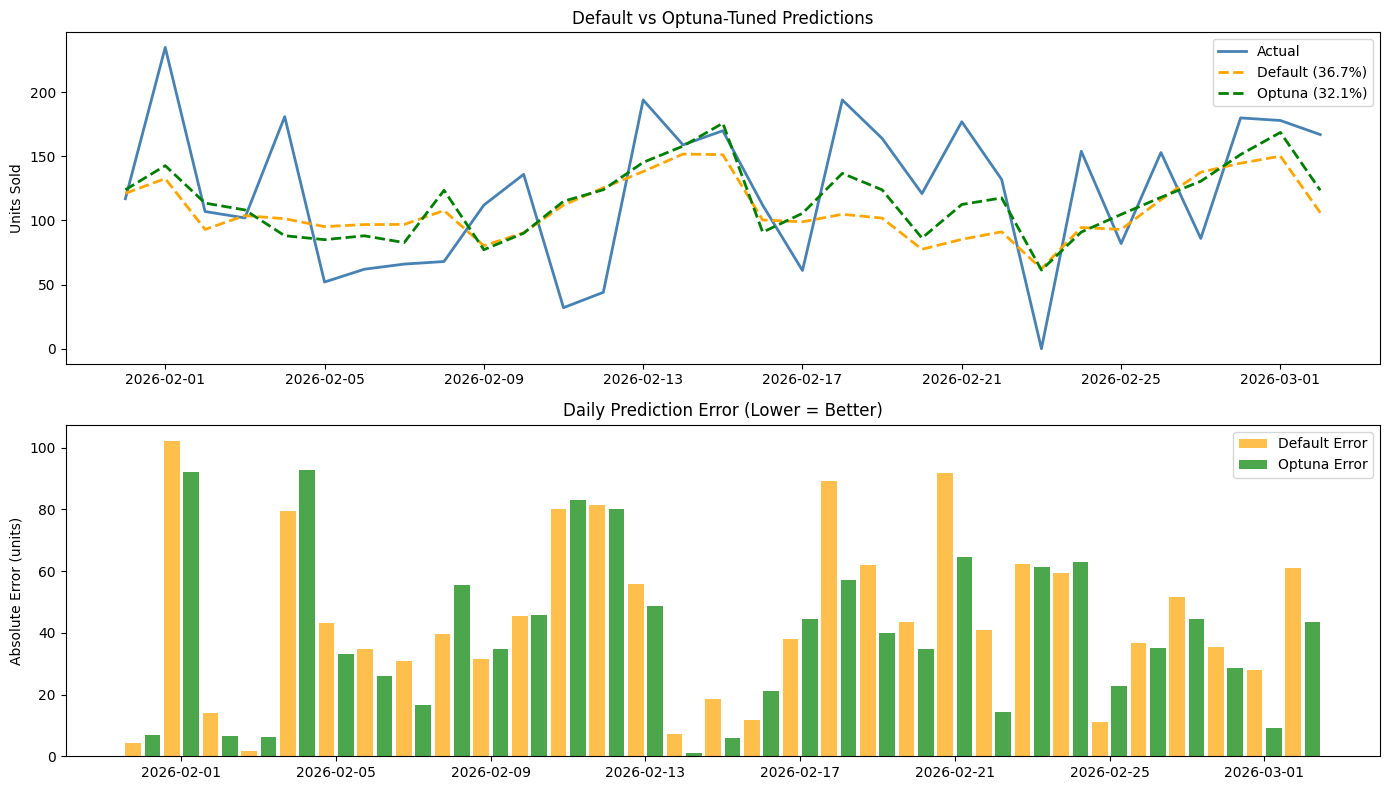

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1: Predictions comparison
dates = y_test.index
axes[0].plot(dates, y_test.values, label="Actual", color="steelblue", linewidth=2)
axes[0].plot(dates, pred_default, label=f"Default ({wmape_default:.1%})", 
             color="orange", linewidth=2, linestyle="--")
axes[0].plot(dates, pred_tuned, label=f"Optuna ({wmape_tuned:.1%})", 
             color="green", linewidth=2, linestyle="--")
axes[0].set_title("Default vs Optuna-Tuned Predictions")
axes[0].set_ylabel("Units Sold")
axes[0].legend()

# Chart 2: Daily error comparison
error_default = np.abs(y_test.values - pred_default)
error_tuned = np.abs(y_test.values - pred_tuned)

axes[1].bar(dates - pd.Timedelta(hours=6), error_default, width=0.4, 
            label=f"Default Error", color="orange", alpha=0.7)
axes[1].bar(dates + pd.Timedelta(hours=6), error_tuned, width=0.4, 
            label=f"Optuna Error", color="green", alpha=0.7)
axes[1].set_title("Daily Prediction Error (Lower = Better)")
axes[1].set_ylabel("Absolute Error (units)")
axes[1].legend()

plt.tight_layout()
plt.show()

 Test across multiple categories

In [12]:
# Let's tune and test for the top 5 categories
test_categories = ["BEVERAGES", "GROCERY I", "PRODUCE", "DAIRY", "MEATS"]

print("=" * 70)
print("  OPTUNA TUNING — Multiple Categories")
print("=" * 70)
print(f"  {'Category':<20s} {'Default':>10s} {'Tuned':>10s} {'Improve':>10s}")
print("-" * 70)

all_results = []

for cat in test_categories:
    cat_data = store1[store1.family == cat].sort_values("date").reset_index(drop=True)
    
    if len(cat_data) < 100:
        print(f"  {cat:<20s} Skipped (not enough data)")
        continue
    
    cat_features = build_features(cat_data, holidays, 
                                   weather_df=weather, events_df=events).dropna()
    cat_feat_cols = get_feature_columns(cat_features)
    
    cat_train = cat_features[cat_features.index < val_start]
    cat_val = cat_features[(cat_features.index >= val_start) & (cat_features.index < test_start)]
    cat_test = cat_features[cat_features.index >= test_start]
    
    if len(cat_train) < 50 or len(cat_val) < 5 or len(cat_test) < 5:
        print(f"  {cat:<20s} Skipped (not enough data in splits)")
        continue
    
    cX_train, cy_train = cat_train[cat_feat_cols], cat_train["sales"]
    cX_val, cy_val = cat_val[cat_feat_cols], cat_val["sales"]
    cX_test, cy_test = cat_test[cat_feat_cols], cat_test["sales"]
    
    # Default
    m_def = xgb.XGBRegressor(**default_params)
    m_def.fit(cX_train, cy_train, eval_set=[(cX_val, cy_val)], verbose=False)
    w_def = compute_wmape(cy_test.values, np.maximum(m_def.predict(cX_test), 0))
    
    # Optuna for this category
    def cat_objective(trial):
        p = {
            "objective": "reg:tweedie",
            "tweedie_variance_power": trial.suggest_float("tp", 1.1, 1.9),
            "n_estimators": 500,
            "max_depth": trial.suggest_int("md", 3, 10),
            "learning_rate": trial.suggest_float("lr", 0.01, 0.20, log=True),
            "subsample": trial.suggest_float("ss", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("cs", 0.4, 1.0),
            "min_child_weight": trial.suggest_int("mcw", 3, 50),
            "reg_alpha": trial.suggest_float("ra", 0.001, 5.0, log=True),
            "reg_lambda": trial.suggest_float("rl", 0.001, 10.0, log=True),
            "random_state": 42,
            "early_stopping_rounds": 30,
        }
        m = xgb.XGBRegressor(**p)
        m.fit(cX_train, cy_train, eval_set=[(cX_val, cy_val)], verbose=False)
        return compute_wmape(cy_val.values, np.maximum(m.predict(cX_val), 0))
    
    cat_study = optuna.create_study(direction="minimize")
    cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=False)
    
    # Train tuned model on test
    tuned_p = {
        "objective": "reg:tweedie",
        "tweedie_variance_power": cat_study.best_params["tp"],
        "n_estimators": 500,
        "max_depth": cat_study.best_params["md"],
        "learning_rate": cat_study.best_params["lr"],
        "subsample": cat_study.best_params["ss"],
        "colsample_bytree": cat_study.best_params["cs"],
        "min_child_weight": cat_study.best_params["mcw"],
        "reg_alpha": cat_study.best_params["ra"],
        "reg_lambda": cat_study.best_params["rl"],
        "random_state": 42,
        "early_stopping_rounds": 30,
    }
    m_tuned = xgb.XGBRegressor(**tuned_p)
    m_tuned.fit(cX_train, cy_train, eval_set=[(cX_val, cy_val)], verbose=False)
    w_tuned = compute_wmape(cy_test.values, np.maximum(m_tuned.predict(cX_test), 0))
    
    improve = (w_def - w_tuned) / w_def * 100
    beat = "✅" if w_tuned < w_def else "❌"
    print(f"  {cat:<20s} {w_def:>9.1%} {w_tuned:>9.1%} {improve:>+9.1f}% {beat}")
    
    all_results.append({"category": cat, "default": w_def, "tuned": w_tuned, "improve": improve})

print("-" * 70)
results_df = pd.DataFrame(all_results)
print(f"  {'AVERAGE':<20s} {results_df['default'].mean():>9.1%} {results_df['tuned'].mean():>9.1%} {results_df['improve'].mean():>+9.1f}%")

  OPTUNA TUNING — Multiple Categories
  Category                Default      Tuned    Improve
----------------------------------------------------------------------
  BEVERAGES                36.7%     33.5%      +8.6% ✅
  GROCERY I                23.2%     21.8%      +6.1% ✅
  PRODUCE                  21.6%     22.4%      -3.6% ❌
  DAIRY                    26.4%     23.8%      +9.8% ✅
  MEATS                    28.5%     30.5%      -6.8% ❌
----------------------------------------------------------------------
  AVERAGE                  27.3%     26.4%      +2.8%


Save the best parameters

In [13]:
import json

# Save Optuna's best params for Beverages so we can use them in the dashboard
best_for_beverages = {
    "objective": "reg:tweedie",
    "tweedie_variance_power": study.best_params["tweedie_power"],
    "n_estimators": 500,
    "max_depth": study.best_params["max_depth"],
    "learning_rate": study.best_params["learning_rate"],
    "subsample": study.best_params["subsample"],
    "colsample_bytree": study.best_params["colsample_bytree"],
    "min_child_weight": study.best_params["min_child_weight"],
    "reg_alpha": study.best_params["reg_alpha"],
    "reg_lambda": study.best_params["reg_lambda"],
    "random_state": 42,
    "early_stopping_rounds": 30,
}

# Save to model registry
from config import MODEL_REGISTRY
MODEL_REGISTRY.mkdir(parents=True, exist_ok=True)

params_path = MODEL_REGISTRY / "optuna_best_params.json"
with open(params_path, "w") as f:
    json.dump(best_for_beverages, f, indent=2)

print(f"✅ Best parameters saved to {params_path}")
print(f"\nTo use these in the dashboard, update the XGBRegressor call to:")
print(f"   model = xgb.XGBRegressor(**best_params)")
print(f"\nBest params:")
for k, v in best_for_beverages.items():
    print(f"   {k}: {v}")

✅ Best parameters saved to c:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\model\registry\optuna_best_params.json

To use these in the dashboard, update the XGBRegressor call to:
   model = xgb.XGBRegressor(**best_params)

Best params:
   objective: reg:tweedie
   tweedie_variance_power: 1.154598742881313
   n_estimators: 500
   max_depth: 3
   learning_rate: 0.13163650264202617
   subsample: 0.6993161710363118
   colsample_bytree: 0.7995975421818298
   min_child_weight: 31
   reg_alpha: 0.002675145651949105
   reg_lambda: 0.34172513110104175
   random_state: 42
   early_stopping_rounds: 30
